In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import math


Next choose graph
--

In [2]:
G = nx.Graph()
G.add_edges_from([(0,1),(0,2),(1,2)])

In [3]:
G = nx.complete_graph(4)

In [4]:
G = nx.Graph()


def readdimacs(filename):

    file = open(filename, 'r')
    lines = file.readlines()
    
    Gd = nx.Graph()

    for line in lines:
        if line[0] == "e":
            vs = [int(s) for s in line.split() if s.isdigit()]
            Gd.add_edge(vs[0]-1, vs[1]-1)
    return Gd

G = readdimacs('dsjc125.9.col')  


Init Coloring
--

In [5]:
class GraphColoring:
    def color(self, method, G, colors, maxSteps, seed = 0):
        self.methods = [self.randomWalk, self.hillClimbing, self.hillClimbingWithRndThreshold]
        self.method = method
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.G = G
        self.maxSteps = maxSteps
        self.colors = colors
        self.nodes = np.zeros(self.G.number_of_nodes(), dtype=int) #ALT: self.rng.integers(0,self.colors,(self.G.number_of_nodes()))
        self.iterations = 0
        self.solved = self.run()
        return self.nodes, self.solved, self.iterations
    def run(self): 
        oddFrame = np.zeros(self.G.number_of_nodes(), dtype=int)
        evenFrame = np.zeros(self.G.number_of_nodes(), dtype=int)
        differenceArray = np.zeros(self.G.number_of_nodes(), dtype=int)
        self.diffBtwnFrames = np.zeros(self.maxSteps, dtype=int)
        self.biggestDiff = 0
        self.thresholdLog = [0,0]
        for step in np.arange(self.maxSteps):
            self.methods[self.method]()
            self.iterations +=1
            if self.iterations%2==0:
                evenFrame = np.array(self.nodes)
            else:
                oddFrame = np.array(self.nodes)
            if self.iterations != 1:
                differenceArray = oddFrame - evenFrame
                self.diff = np.count_nonzero(differenceArray)
                self.diffBtwnFrames[self.iterations-1] = self.diff
            if self.isColoring():
                return True
        return False
    def randomWalk(self):
        for idx, node in enumerate(self.nodes):
            self.nodes[idx] = self.rng.integers(0,self.colors)
    def hillClimbing(self):
        colOccurrence = np.zeros(self.colors, dtype=int)
        for idx, node in enumerate(self.nodes):
            colOccurrence.fill(0)
            for i in self.G.neighbors(idx):
                colOccurrence[self.nodes[i]] +=1
            minCols = np.where(colOccurrence == colOccurrence.min())
            newCol = self.rng.choice(minCols[0], 1)
            self.nodes[idx] = newCol
    def hillClimbingWithRndThreshold(self):
        colOccurrence = np.zeros(self.colors, dtype=int)
        ratio = 1
        if self.iterations > 2:
            if self.diff > self.biggestDiff:
                self.biggestDiff = self.diff
            ratio = self.diff / self.biggestDiff
            self.thresholdLog.append(self.biggestDiff*0.2)
        for idx, node in enumerate(self.nodes):
            colOccurrence.fill(0)
            if ratio < 0.2:
                jumpChance = 0.001
            else:
                jumpChance = 0
            if jumpChance > self.rng.random():
                newCol = self.rng.integers(self.colors)
            else:
                for i in self.G.neighbors(idx):
                    colOccurrence[self.nodes[i]] +=1
                minIdxs = np.where(colOccurrence == colOccurrence.min())
                newCol = self.rng.choice(minIdxs[0], 1)
            self.nodes[idx] = newCol     
    def isColoring(self):
        for idx, node in enumerate(self.nodes):
            for i in self.G.neighbors(idx):
                if self.nodes[i] == node:
                    return False
        return True
    def plot(self, G, cols): #Draws graphs on top of each other
        k = np.max(cols)
        symbols = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F']
        colmap = ["#"+''.join(self.rng.choice(symbols, 6)) for i in range(k+1)]

        colors = [colmap[c] for c in cols]

        nx.draw(G, node_color=colors, with_labels=True)
    def show(self):
        print('Solved:',self.solved,', Iterations:',self.iterations, 'Difference progress:')
        self.linPlot()
        #self.plot(self.G,self.nodes)
    def linPlot(self):
        sliceEnd = -self.maxSteps+self.iterations
        if sliceEnd > -1:
            sliceEnd = self.maxSteps
            
        fig, ax = plt.subplots()
        fx = self.diffBtwnFrames[1:sliceEnd]
        x = np.arange(fx.size)

        ax.plot(x+1, fx, label='Difference')
        if self.method == 2:
            ax.plot(x+1, self.thresholdLog, label='Threshold')
        ax.legend()

        '''
        fx = self.diffBtwnFrames[1:sliceEnd]
        x = np.arange(fx.size)
        plt.plot(x+1, fx)  
        '''
    

def findSmallest(class_, method, G, maxSteps, seed = 0):
    up = G.number_of_nodes()
    low = 0
    mid = 0
    while up - low > 1:
        mid = math.floor((up+low)/2)
        graph = class_()
        cols, solved, iterations = graph.color(method, G, mid, maxSteps, seed)
        if solved:
            up = mid
        else:
            low = mid
    return up
    
#basic performance mesurement, not perfected
def performance(class_, method, G, maxColors, maxSteps, cycles):
    iterationsArray = np.empty(cycles, dtype=int)
    for cycle in np.arange(cycles):
        graph = class_()
        cols, solved, iterations = graph.color(method, G, maxColors, maxSteps, cycle)
        if not solved: #TODO Improve code by not abandoning e.g. increase maxSteps 2x and continue
            print('Abandoned, reached max number of steps in cycle', cycle,'. Incese maxSteps or make sure the graph is colorable with',maxColors,'colors')
            graph.show()
            return 
        iterationsArray[cycle] = iterations
    return np.sum(iterationsArray) / cycles, np.min(iterationsArray), np.max(iterationsArray), iterationsArray

And choose operation
--

Solved: True , Iterations: 107 Difference progress:


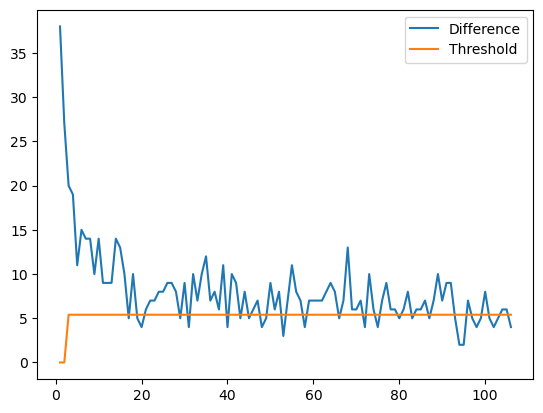

In [6]:
graph = GraphColoring()
graph.color(2, G, 44, 1000, )
graph.show()

In [50]:
findSmallest(GraphColoring, 2, G, 1000, )

13

Abandoned, reached max number of steps in cycle 7 . Incese maxSteps or make sure the graph is colorable with 44 colors
Solved: False , Iterations: 1000 Difference progress:


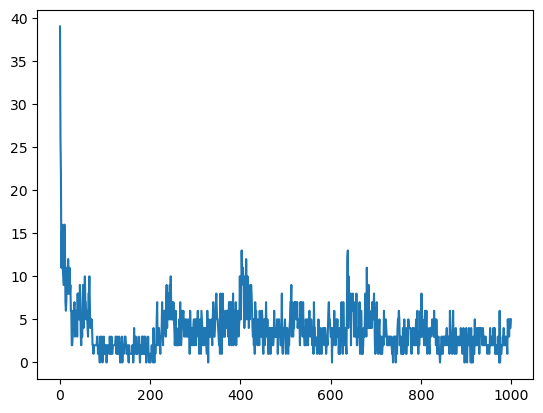

In [83]:
performance(GraphColoring, 2, G, 44, 10000, 1000)

In [90]:
performance(GraphColoring, 2, G, 44, 10000, 1000)

(534.106,
 38,
 2744,
 array([ 107,  812,  464,  606, 1009,  648,  143,  148,  266,  733,  151,
         305,  741,   92,  213,  699,  140,  193,  437,   82, 1274, 1002,
        1165,  430,  742,  516,  364,  141,  471, 1174, 1349,  468,  246,
         409,  567,  494,   83,   93,  191, 1249,   90,  111,  616,  219,
         928,  997,  735,  370,  251,   52,  971,  339, 1032,  145, 2336,
         961, 1411,  301,   47, 1416,  293,  651,  260,  232,  270, 1336,
        1004,  671,   90,  488,  194,  177, 1197,  158,  341,  232,  589,
         333,  832,  439,  132,  845,  669,  684, 1189,  311,  237,  149,
         739,  354,  736,  531,  300,  335,  142,  411,  328, 1124,  367,
        2008,  200,  186,  133,  766,  131,  858,  162,  365,   78,  115,
         568,  570,  503,  145,  245,  518,  324,  139,  167,  122,  427,
         911,  174,  415,  835,  418,  304,  243,  306, 1212,  439,  216,
         452,  277,  114, 1018,  221,  412,  368,  410,  277,  727,  203,
         613,  9